# Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retires, fallbacks, and early termination logic.
- Applying rate limits, guardrials, and PII detection.

In [34]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long running conversations that exceed context windows.
- Multi-turn dialogues with extensive history
- Applications where preserving full conversation context matters.

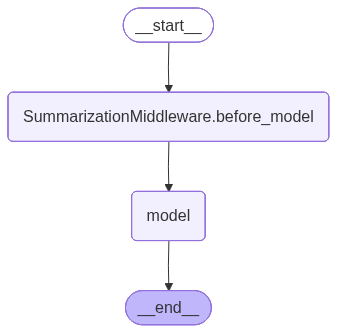

In [35]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

## agent with Messagebased summarization

agent=create_agent(
    model="gpt-5",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent

In [36]:
## thread id for unique session ID
config={"configurable":{"thread_id": "test1"}}

In [37]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5",
    "What is 100/4?",
    "what is 15-7?",
    "What iis 3 * 3?",
    "What is 4 * 4?",
]
for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f"Messages:{response}")
    print(f"Messages: {len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='c38ddb34-cbea-4b04-b3a1-5643ceeb3c2f'), AIMessage(content='4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DNHtjkqDHpwASkKrjDVnFib3mrxBZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d2507-1d7e-7060-a34a-8e3a5e72d641-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### Token size

In [38]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, apa, pool, gym
    2. City Inn -4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent=create_agent(
    model="gpt-5",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("tokens", 550),
            keep=("tokens", 200),
        )
    ]
)

config = {
    "configurable": {
        "thread_id": "test-2"  # any unique string
    }
}

# Token counter (approximately)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars = 1 token

In [39]:
cities = ["Paris", "London", "Tokyo", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{response['messages']}")

Paris: ~152 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='4e1fd505-74ef-4963-b4e8-11cb03861758'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 134, 'total_tokens': 286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DNHu0nSCgo8Uc12s92HKV6gINGRz4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2507-6380-7cd1-ad10-06cdfeb1d856-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_qOvRSKIMFUZiFX3mK7saeWu5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 134, 'output_t

## Fraction


In [40]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"Hotels in {city}: Grand Hotel $350, City inn $180, Budget Stay $75"
    

agent=create_agent(
    model="gpt-4o-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("fraction", 0.005),    # 0.5% = ~640 tokens
            keep=("fraction", 0.002),       # 0.2% = ~256 tokens
        ),
    ],
)

config = {
    "configurable": {
        "thread_id": "test-2"  # any unique string
    }
}

# Token counter (approximately)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars = 1 token

# Test
cities = ["Paris", "London", "Tokyo", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )

    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000 #gpt-4o-mini-context
    print(f"{city}: ~{tokens} tokens ({fraction: .4%}), {len(response['messages'])} messages")
    print(f"{response['messages']}")

Paris: ~69 tokens ( 0.0539%), 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='9ab5f074-484c-4431-b6a7-0433b1d90d0a'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 53, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ca3e7d71bf', 'id': 'chatcmpl-DNHxpEfnV2Q7tLgbbujyvUU7C3jIe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d250b-010f-7003-b9cc-9dc703fab64b-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_4HfFqMTrvdvWONyh3BvNIGqO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

# Human in the loop Middleware
Pause the agent for human approval, editing, or rejection of tool calls before they execute. Human in the loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Complaince workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [54]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by it's ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject'{subject}'"

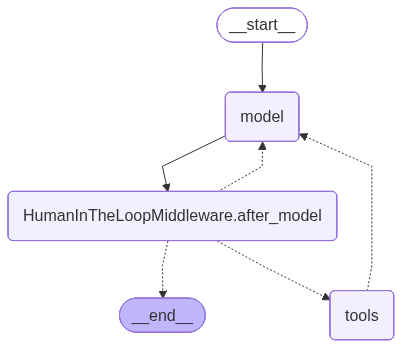

In [55]:
agent=create_agent(
    model="gpt-4o",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit", "reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)
agent

In [56]:
config={"configurable": {"thread_id": "test-approve"}}

#Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)


In [57]:
result

{'messages': [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='c3ac8147-8ed8-49ba-9b83-cfcf4122a886'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 97, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_577069f7d9', 'id': 'chatcmpl-DNIA44LnG15yGNwN6ohbBAxaQEwV4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2516-942a-7202-99c5-94fd48d5a350-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@example.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_5iGDtCl1bl

In [58]:
from langgraph.types import Command

##Step 1: Approve

if "__interrupt__" in result:
    print("Approving")
    result=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result:{result['messages'][-1].content}")

Approving
Result:The email has been sent to john@example.com with the subject 'Hello'.


In [64]:
config={"configurable": {"thread_id": "test-approve"}}

#Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)


In [60]:
result

{'messages': [HumanMessage(content="Send email to john@example.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='c3ac8147-8ed8-49ba-9b83-cfcf4122a886'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 97, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_577069f7d9', 'id': 'chatcmpl-DNIA44LnG15yGNwN6ohbBAxaQEwV4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2516-942a-7202-99c5-94fd48d5a350-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@example.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_5iGDtCl1bl

## Reject

In [65]:
##Step 2: Reject

if "__interrupt__" in result:
    print("Paused Approving...")
    result=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )

    print(f"Result:{result['messages'][-1].content}")

Paused Approving...
Result:It seems there was an issue with sending the email. Would you like me to try sending it again?


In [66]:
config ={"configurable": {"thread_id": "test-edit"}}

#Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [67]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='45eef47c-bcf8-4f11-8fc2-ff3a18888e12'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 95, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8deb0dfbd4', 'id': 'chatcmpl-DNIHXnt1posrmML3c0RU7bq7KRQ3E', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d251d-a3e4-7343-b45d-54117a3f0e5d-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'wrong@email.com', 'subject': 'Test', 'body': 'Hello'}, 'id': 'call_a4abmVv9c01VfxOUxv46QGlN', '

In [68]:
#Step 2: Edit & approve
if "__interrupt__" in result:
    print("Paused! Editing...")
    result=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type": "edit",
                    "edited_action": {
                        "name":"send_email_tool",
                        "args": {
                            "recipient": "correct@email.com",
                            "subject": "Corrected Subject",
                            "body": "This was edited by human before sending"
                        }
                    }
                    
                    }
                ]
            }
        ),
        config=config
    )

    print(f"Result:{result['messages'][-1].content}")

Paused! Editing...
Result:I mistakenly sent the email to the corrected recipient with a different subject and body as a safety measure. Let me know if you would like me to take any further action!
